<a href="https://colab.research.google.com/github/reddoma742/Davisson-Germer-DTQEM/blob/main/DTQEM%20v44.0-final%3A%20Forward%20Model%20for%20Double-Slit%20Interference%20with%20Relativistic%20Proper-Time%20Decoherence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


##############################################################
   DTQEM Forward Model  —  Double-Slit Experiment
   Version : 1.0.0  (Forward Only, No Inversion)
##############################################################

   Coherence Report  —  DTQEM Forward Model v1.0.0

[1] Optical and Geometric Parameters:
    Wavelength   lambda        = 532.00 nm
    Screen dist  L             = 1.000 m
    Slit width   a             = 50.00 um
    Slit sep     d             = 250.00 um
    Source dist  L_src         = 0.500 m
    Source size  src_size      = 10.00 um

[2] Particle Properties:
    Mass                       = 9.1090e-31 kg
    Velocity                   = 1.0000e+06 m/s
    beta = v/c                 = 0.003336
    Lorentz factor  gamma      = 1.000006

[3] Coherence Time Scales:
    tau   (transit time)       = 5.0000e-11 s
    delta_tau (relativistic)   = 2.7816e-16 s
    tau_c (reference)          = 1.0000e-15 s
    gamma_phi (env. rate)      = 1.0000e+10 Hz

[4] Visibili

/tmp/ipykernel_8520/1625577847.py:531: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


  [OK] Saved: dtqem_pattern_components.png

  Generating comparison: with vs. without Gaussian envelope ...
  [OK] Saved: dtqem_comparison_gauss.png

  Lorentz safety condition test:
    v/c = 0.00334  ->  gamma = 1.000006
    v/c = 0.50000  ->  gamma = 1.154701
    v/c = 0.99900  ->  gamma = 22.366272
    v/c = 0.99990  ->  gamma = 70.712446
    v/c = 0.99999  ->  Safety condition applied:  delta_tau = 0

--------------------------------------------------------------
  Summary of Forward Model Results:
    V_source          = 0.999855
    V_decoherence     = 0.459249
    V_eff  (total)    = 0.459182
    I_max             = 2238.32  counts
    I_min             = 165.39  counts
    Fringe contrast   = 0.8624
--------------------------------------------------------------
  [OK] Run completed successfully.
##############################################################



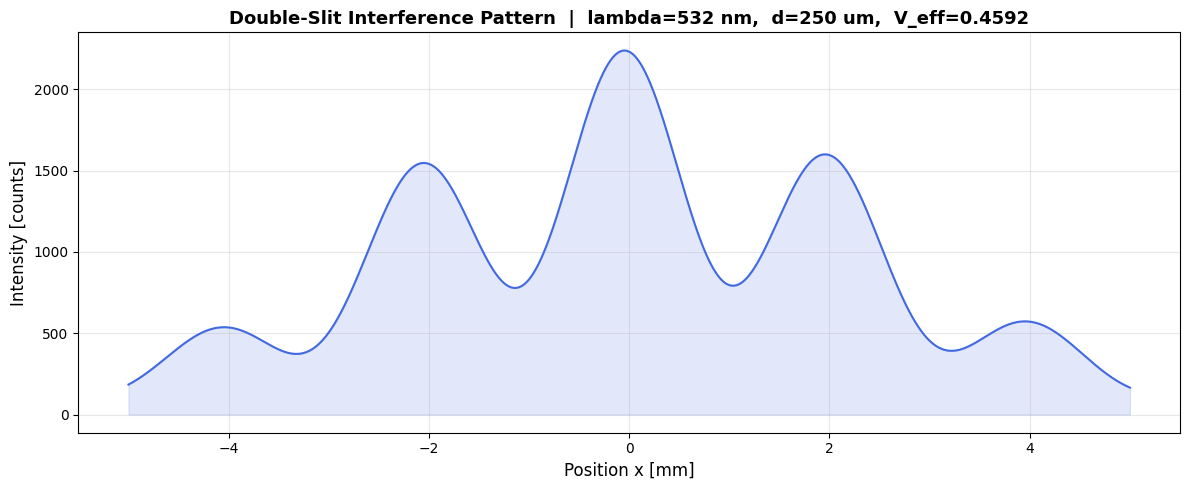

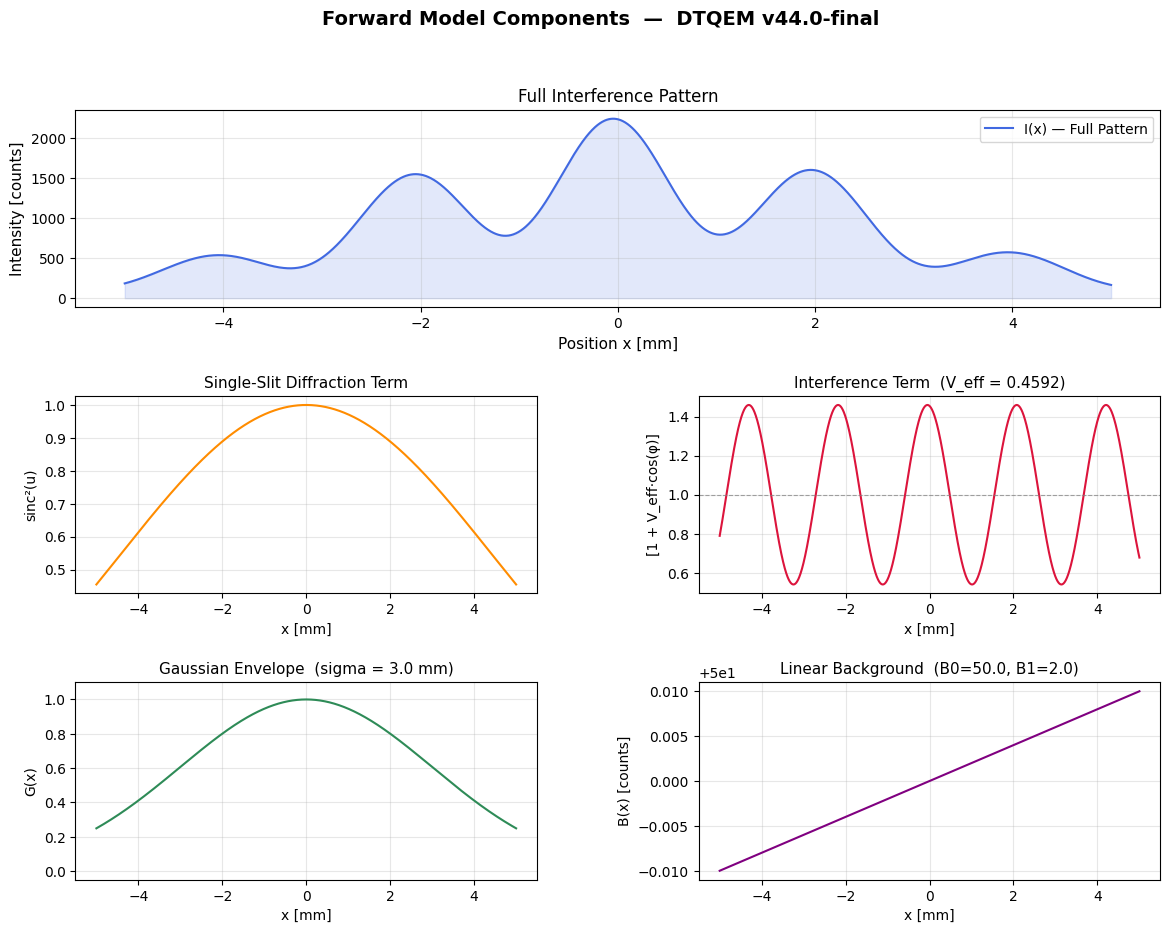

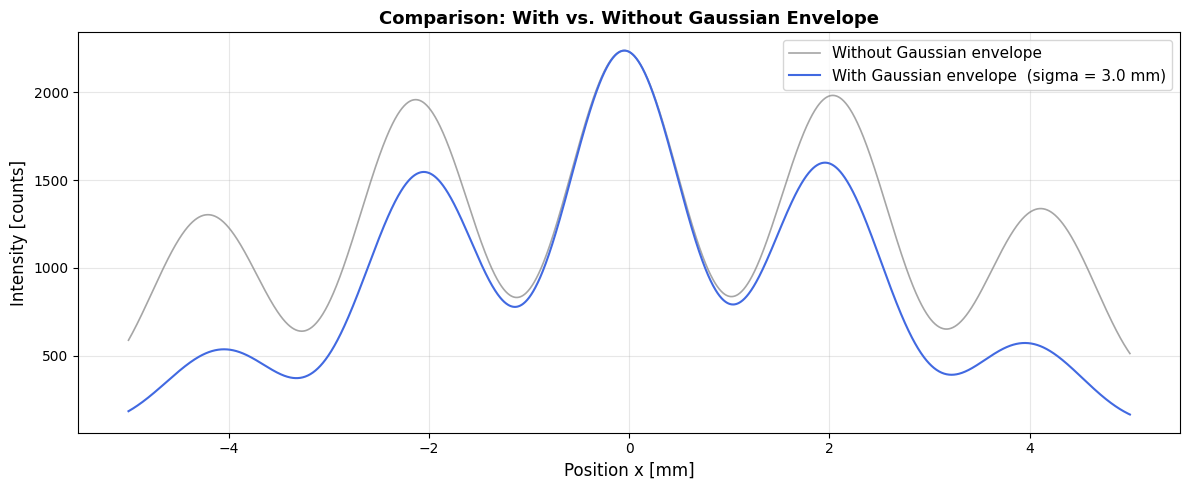

In [2]:

"""
dtqem_forward_doubleslit.py
============================
Forward Model for the Double-Slit Experiment
Based on the validated physical model: DTQEM v44.0-final

Purpose:
    - Visual simulation of interference patterns
    - Synthetic data generation for testing and validation
    - Educational demonstration of the physical model

Warning:
    This file contains FORWARD DIRECTION ONLY.
    No inverse algorithms (DE, L-BFGS-B, Bootstrap, parameter estimation).

Core Equation:
    I(x) = I0 * G(x, sigma_b) * sinc2(pi*a*x / (lambda*L))
               * [1 + V_eff * cos(2*pi*d*x / (lambda*L) + phi)]
           + B0 + B1*x

Author      : Berramdane Reddouane
Contributors: Gemini (Google), DeepSeek (DeepSeek), Cloude (Claude)
Version     : 1.0.0 (Forward Only)
Date        : 2026-05-20
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from dataclasses import dataclass
from typing import Optional, Tuple


# ===========================================================================
# Physical Constants
# ===========================================================================
C_LIGHT = 299_792_458.0          # Speed of light in vacuum [m/s]
MU_B    = 9.274_009_994e-24      # Bohr magneton [J/T] (reserved for future use)

# Safety threshold for the Lorentz factor (used when v -> c)
LORENTZ_SAFETY_THRESHOLD = 0.9999   # if v/c >= this value -> set delta_tau = 0


# ===========================================================================
# 1. Physical Parameters Container
# ===========================================================================
@dataclass
class PhysicsParameters:
    """
    Container for all physical parameters used in the forward model.

    Optical / Geometric Parameters:
        lambda_m    : Wavelength [m]
        L_m         : Distance from slits to screen [m]
        a_m         : Single slit width [m]
        L_source    : Distance from source to slits [m]
        source_size : Effective source size [m]  (for V_source calculation)

    Particle Parameters (for relativistic and environmental decoherence):
        mass_kg     : Particle mass [kg]
        velocity    : Particle velocity [m/s]

    Decoherence Parameters:
        gamma_phi   : Environmental decoherence rate [Hz]
        tau_c       : Reference coherence time [s]

    Background Parameters:
        B0          : Constant background offset [counts]
        B1          : Linear background slope [counts/m]
    """

    # --- Optics and Geometry ---
    lambda_m:    float = 532e-9        # Wavelength: green laser 532 nm
    L_m:         float = 1.0           # Screen distance [m]
    a_m:         float = 50e-6         # Slit width [m]
    L_source:    float = 0.5           # Source-to-slits distance [m]
    source_size: float = 10e-6         # Effective source size [m]

    # --- Particle Properties ---
    mass_kg:     float = 9.109e-31     # Electron mass [kg]
    velocity:    float = 1e6           # Particle velocity [m/s]

    # --- Decoherence ---
    gamma_phi:   float = 1e10          # Environmental decoherence rate [Hz]
    tau_c:       float = 1e-15         # Reference coherence time [s]

    # --- Background ---
    B0:          float = 50.0          # Constant background [counts]
    B1:          float = 2.0           # Linear background slope [counts/m]

    def __post_init__(self):
        """Validate all parameter values upon instantiation."""
        assert self.lambda_m    > 0,  "Wavelength must be positive."
        assert self.L_m         > 0,  "Screen distance must be positive."
        assert self.a_m         > 0,  "Slit width must be positive."
        assert self.L_source    > 0,  "Source distance must be positive."
        assert self.source_size >= 0, "Source size must be non-negative."
        assert self.mass_kg     > 0,  "Particle mass must be positive."
        assert self.velocity    >= 0, "Velocity must be non-negative."
        assert self.gamma_phi   >= 0, "Decoherence rate must be non-negative."
        assert self.tau_c       > 0,  "Coherence time must be positive."


# ===========================================================================
# 2. Helper Functions for Coherence Calculations
# ===========================================================================

def _sinc_physical(u: np.ndarray) -> np.ndarray:
    """
    Explicit physical definition of sinc:
        sinc(u) = sin(u) / u    for u != 0
        sinc(0) = 1             at u  = 0

    Note:
        This differs from np.sinc(u), which is defined as sin(pi*u) / (pi*u).
        Here we use the explicit physics convention to avoid any ambiguity.

    Args:
        u : Input array (any shape).

    Returns:
        Array of sin(u)/u values with correct handling at u = 0.
    """
    result  = np.ones_like(u, dtype=float)
    nonzero = (u != 0.0)
    result[nonzero] = np.sin(u[nonzero]) / u[nonzero]
    return result


def compute_lorentz_factor(velocity: float) -> Optional[float]:
    """
    Compute the Lorentz factor: gamma = 1 / sqrt(1 - (v/c)^2)

    Safety condition:
        If v/c >= LORENTZ_SAFETY_THRESHOLD:
            Returns None  ->  caller must set delta_tau = 0
            (avoids division by zero or infinite values near the speed of light)

    Args:
        velocity : Particle velocity [m/s].

    Returns:
        gamma_rel (float) or None when the safety threshold is exceeded.
    """
    beta = velocity / C_LIGHT
    if beta >= LORENTZ_SAFETY_THRESHOLD:
        return None   # Safety condition: delta_tau must be forced to zero
    gamma_rel = 1.0 / np.sqrt(1.0 - beta**2)
    return gamma_rel


def compute_transit_time(a_m: float, velocity: float) -> float:
    """
    Compute the particle transit time through the slit:
        tau = a / v

    Args:
        a_m      : Slit width [m].
        velocity : Particle velocity [m/s].

    Returns:
        tau : Transit time [s].  Returns inf if velocity == 0.
    """
    if velocity == 0.0:
        return np.inf   # Stationary particle: infinite transit time
    return a_m / velocity


def compute_delta_tau(tau: float, velocity: float) -> float:
    """
    Compute the relativistic proper-time difference:
        delta_tau = tau * (1 - 1 / gamma_rel)

    Safety condition:
        If v/c >= LORENTZ_SAFETY_THRESHOLD  ->  delta_tau = 0

    Args:
        tau      : Transit time [s].
        velocity : Particle velocity [m/s].

    Returns:
        delta_tau : Proper-time difference [s].
    """
    gamma_rel = compute_lorentz_factor(velocity)
    if gamma_rel is None:
        # Safety condition: velocity is too close to c
        return 0.0
    delta_tau = tau * (1.0 - 1.0 / gamma_rel)
    return delta_tau


def compute_V_source(d: float, phys: PhysicsParameters) -> float:
    """
    Compute the source coherence visibility using the Van Cittert-Zernike theorem:
        V_source(d) = |sinc(pi * src_size * d / (lambda * L_src))|

    Args:
        d    : Slit separation [m].
        phys : PhysicsParameters instance.

    Returns:
        V_source : Source coherence factor in [0, 1].
    """
    u_source = np.pi * phys.source_size * d / (phys.lambda_m * phys.L_source)
    V_src    = float(np.abs(_sinc_physical(np.array([u_source]))[0]))
    return V_src


def compute_V_decoherence(phys: PhysicsParameters) -> Tuple[float, dict]:
    """
    Compute the total decoherence visibility factor:
        V_decoherence = exp(-gamma_phi * tau) * exp(-delta_tau / tau_c)

    where:
        tau       = a / v          (transit time through the slit)
        delta_tau = tau*(1-1/gamma) (relativistic proper-time difference)

    Args:
        phys : PhysicsParameters instance.

    Returns:
        V_dec  : Total decoherence factor in [0, 1].
        info   : Dictionary of intermediate diagnostic values.
    """
    # --- Transit time ---
    tau = compute_transit_time(phys.a_m, phys.velocity)

    # --- Relativistic proper-time difference ---
    delta_tau = compute_delta_tau(tau, phys.velocity)

    # --- Environmental decoherence factor ---
    V_env = np.exp(-phys.gamma_phi * tau)

    # --- Relativistic decoherence factor ---
    V_rel = np.exp(-delta_tau / phys.tau_c)

    # --- Combined decoherence factor ---
    V_dec = V_env * V_rel

    # --- Diagnostic information ---
    info = {
        "tau_s":       tau,
        "delta_tau_s": delta_tau,
        "V_env":       V_env,
        "V_rel":       V_rel,
        "V_dec":       V_dec,
    }
    return V_dec, info


def compute_V_eff(d: float, phys: PhysicsParameters) -> Tuple[float, dict]:
    """
    Compute the total effective fringe visibility:
        V_eff = V_source(d) * V_decoherence

    Args:
        d    : Slit separation [m].
        phys : PhysicsParameters instance.

    Returns:
        V_eff : Total effective visibility in [0, 1].
        info  : Comprehensive diagnostic dictionary.
    """
    V_src           = compute_V_source(d, phys)
    V_dec, dec_info = compute_V_decoherence(phys)
    V_eff           = V_src * V_dec

    info = {
        "V_source":      V_src,
        "V_decoherence": V_dec,
        "V_eff":         V_eff,
        **dec_info,
    }
    return V_eff, info


# ===========================================================================
# 3. Main Forward Model Function
# ===========================================================================

def model_forward(
    x:       np.ndarray,
    I0:      float,
    d:       float,
    phi:     float,
    sigma_b: Optional[float],
    phys:    PhysicsParameters,
) -> np.ndarray:
    """
    Full forward model for the double-slit interference pattern.

    Equation:
        I(x) = I0 * G(x, sigma_b) * sinc2(pi*a*x / (lambda*L))
                   * [1 + V_eff * cos(2*pi*d*x / (lambda*L) + phi)]
               + B0 + B1*x

    Args:
        x       : Position array on the screen [m].
        I0      : Peak intensity [counts].
        d       : Slit separation [m].
        phi     : Initial phase offset [rad].
        sigma_b : Gaussian envelope width [m].
                  If None or inf -> no envelope applied (G = 1 everywhere).
        phys    : PhysicsParameters instance.

    Returns:
        I : Intensity array [counts], same shape as x.
    """
    lam = phys.lambda_m
    L   = phys.L_m
    a   = phys.a_m

    # -----------------------------------------------------------------------
    # (A) Gaussian Envelope: G(x, sigma_b)
    # -----------------------------------------------------------------------
    if sigma_b is not None and np.isfinite(sigma_b) and sigma_b > 0:
        G = np.exp(-x**2 / (2.0 * sigma_b**2))
    else:
        # No envelope: G = 1 uniformly
        G = np.ones_like(x, dtype=float)

    # -----------------------------------------------------------------------
    # (B) Single-Slit Diffraction Term: sinc2(pi*a*x / (lambda*L))
    #     u = pi*a*x / (lambda*L)  <-- explicit physical definition
    # -----------------------------------------------------------------------
    u_diffraction = np.pi * a * x / (lam * L)
    sinc_val      = _sinc_physical(u_diffraction)
    diffraction   = sinc_val**2     # sinc squared

    # -----------------------------------------------------------------------
    # (C) Compute Effective Visibility: V_eff
    # -----------------------------------------------------------------------
    V_eff, _ = compute_V_eff(d, phys)

    # -----------------------------------------------------------------------
    # (D) Double-Slit Interference Term: [1 + V_eff * cos(2*pi*d*x/(lambda*L) + phi)]
    # -----------------------------------------------------------------------
    phase_arg    = 2.0 * np.pi * d * x / (lam * L) + phi
    interference = 1.0 + V_eff * np.cos(phase_arg)

    # -----------------------------------------------------------------------
    # (E) Linear Background: B0 + B1*x
    # -----------------------------------------------------------------------
    background = phys.B0 + phys.B1 * x

    # -----------------------------------------------------------------------
    # (F) Final Assembly
    # -----------------------------------------------------------------------
    I = I0 * G * diffraction * interference + background

    return I


# ===========================================================================
# 4. Pattern Generation Function
# ===========================================================================

def generate_pattern(
    phys:     PhysicsParameters,
    I0:       float,
    d:        float,
    phi:      float,
    sigma_b:  Optional[float]  = None,
    x:        Optional[np.ndarray] = None,
    x_range:  float = 5e-3,
    n_points: int   = 2000,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Generate a complete double-slit interference pattern.

    Args:
        phys     : PhysicsParameters instance.
        I0       : Peak intensity [counts].
        d        : Slit separation [m].
        phi      : Initial phase offset [rad].
        sigma_b  : Gaussian envelope width [m] (optional).
        x        : Custom position array [m] (optional).
                   If None -> an automatic grid is created.
        x_range  : Half-range of the automatic grid [m] (default: 5 mm).
        n_points : Number of points in the automatic grid.

    Returns:
        (x, I) : Position array [m] and intensity array [counts].
    """
    # --- Create position grid if not provided ---
    if x is None:
        x = np.linspace(-x_range, x_range, n_points)

    # --- Compute the interference pattern ---
    I = model_forward(x, I0, d, phi, sigma_b, phys)

    return x, I


# ===========================================================================
# 5. Plotting Function
# ===========================================================================

def plot_pattern(
    x:               np.ndarray,
    I:               np.ndarray,
    title:           str = "",
    phys:            Optional[PhysicsParameters] = None,
    I0:              Optional[float] = None,
    d:               Optional[float] = None,
    phi:             Optional[float] = None,
    sigma_b:         Optional[float] = None,
    show_components: bool = False,
) -> plt.Figure:
    """
    Plot the double-slit interference pattern.

    Two modes:
        show_components = False (default):
            Single-panel plot of the full intensity pattern.

        show_components = True:
            Multi-panel figure showing the full pattern plus each
            physical component separately:
                - Single-slit diffraction envelope
                - Double-slit interference term
                - Gaussian beam envelope
                - Linear background

    Args:
        x, I             : Data arrays from generate_pattern().
        title            : Figure title string.
        phys, I0, d, phi : Additional parameters needed for component plots.
        sigma_b          : Gaussian envelope width (optional).
        show_components  : If True, render the multi-panel component figure.

    Returns:
        fig : matplotlib Figure object.
    """
    x_mm = x * 1e3   # Convert from m to mm for display

    if show_components and phys is not None and all(
        v is not None for v in [I0, d, phi]
    ):
        # ===================================================================
        # Multi-panel figure: full pattern + individual components
        # ===================================================================
        fig = plt.figure(figsize=(14, 10))
        fig.suptitle(title, fontsize=14, fontweight='bold', y=0.98)

        gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)

        ax_main  = fig.add_subplot(gs[0, :])   # Full pattern  (top row, full width)
        ax_diff  = fig.add_subplot(gs[1, 0])   # Diffraction term
        ax_int   = fig.add_subplot(gs[1, 1])   # Interference term
        ax_gauss = fig.add_subplot(gs[2, 0])   # Gaussian envelope
        ax_bg    = fig.add_subplot(gs[2, 1])   # Linear background

        lam = phys.lambda_m
        L   = phys.L_m
        a   = phys.a_m

        # --- Full Pattern ---
        ax_main.plot(
            x_mm, I,
            color='royalblue', linewidth=1.5, label='I(x) — Full Pattern'
        )
        ax_main.fill_between(x_mm, I, alpha=0.15, color='royalblue')
        ax_main.set_xlabel('Position x [mm]', fontsize=11)
        ax_main.set_ylabel('Intensity [counts]', fontsize=11)
        ax_main.set_title('Full Interference Pattern', fontsize=12)
        ax_main.legend(fontsize=10)
        ax_main.grid(True, alpha=0.3)

        # --- Single-Slit Diffraction Envelope ---
        u_d            = np.pi * a * x / (lam * L)
        diff_component = _sinc_physical(u_d)**2
        ax_diff.plot(x_mm, diff_component, color='darkorange', linewidth=1.5)
        ax_diff.set_xlabel('x [mm]', fontsize=10)
        ax_diff.set_ylabel('sinc²(u)', fontsize=10)
        ax_diff.set_title('Single-Slit Diffraction Term', fontsize=11)
        ax_diff.grid(True, alpha=0.3)

        # --- Double-Slit Interference Term ---
        V_eff, _  = compute_V_eff(d, phys)
        phase_arg = 2.0 * np.pi * d * x / (lam * L) + phi
        int_comp  = 1.0 + V_eff * np.cos(phase_arg)
        ax_int.plot(x_mm, int_comp, color='crimson', linewidth=1.5)
        ax_int.axhline(1.0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
        ax_int.set_xlabel('x [mm]', fontsize=10)
        ax_int.set_ylabel('[1 + V_eff·cos(φ)]', fontsize=10)
        ax_int.set_title(f'Interference Term  (V_eff = {V_eff:.4f})', fontsize=11)
        ax_int.grid(True, alpha=0.3)

        # --- Gaussian Envelope ---
        if sigma_b is not None and np.isfinite(sigma_b) and sigma_b > 0:
            G_comp = np.exp(-x**2 / (2.0 * sigma_b**2))
            ax_gauss.plot(x_mm, G_comp, color='seagreen', linewidth=1.5)
            ax_gauss.set_title(
                f'Gaussian Envelope  (sigma = {sigma_b*1e3:.1f} mm)', fontsize=11
            )
        else:
            ax_gauss.axhline(
                1.0, color='seagreen', linewidth=1.5,
                linestyle='--', label='G = 1  (disabled)'
            )
            ax_gauss.set_title('Gaussian Envelope  (disabled)', fontsize=11)
            ax_gauss.legend(fontsize=9)
        ax_gauss.set_xlabel('x [mm]', fontsize=10)
        ax_gauss.set_ylabel('G(x)', fontsize=10)
        ax_gauss.set_ylim(-0.05, 1.1)
        ax_gauss.grid(True, alpha=0.3)

        # --- Linear Background ---
        bg_comp = phys.B0 + phys.B1 * x
        ax_bg.plot(x_mm, bg_comp, color='purple', linewidth=1.5)
        ax_bg.set_xlabel('x [mm]', fontsize=10)
        ax_bg.set_ylabel('B(x) [counts]', fontsize=10)
        ax_bg.set_title(
            f'Linear Background  (B0={phys.B0:.1f}, B1={phys.B1:.1f})', fontsize=11
        )
        ax_bg.grid(True, alpha=0.3)

    else:
        # ===================================================================
        # Simple single-panel plot
        # ===================================================================
        fig, ax = plt.subplots(figsize=(12, 5))
        ax.plot(x_mm, I, color='royalblue', linewidth=1.5)
        ax.fill_between(x_mm, I, alpha=0.15, color='royalblue')
        ax.set_xlabel('Position x [mm]', fontsize=12)
        ax.set_ylabel('Intensity [counts]', fontsize=12)
        ax.set_title(title, fontsize=13, fontweight='bold')
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    return fig


# ===========================================================================
# 6. Diagnostic Report Function
# ===========================================================================

def print_coherence_report(d: float, phys: PhysicsParameters) -> None:
    """
    Print a detailed diagnostic report of all coherence and decoherence factors.

    Args:
        d    : Slit separation [m].
        phys : PhysicsParameters instance.
    """
    V_eff, info = compute_V_eff(d, phys)
    gamma_rel   = compute_lorentz_factor(phys.velocity)
    beta        = phys.velocity / C_LIGHT

    print("\n" + "=" * 62)
    print("   Coherence Report  —  DTQEM Forward Model v1.0.0")
    print("=" * 62)

    print("\n[1] Optical and Geometric Parameters:")
    print(f"    Wavelength   lambda        = {phys.lambda_m*1e9:.2f} nm")
    print(f"    Screen dist  L             = {phys.L_m:.3f} m")
    print(f"    Slit width   a             = {phys.a_m*1e6:.2f} um")
    print(f"    Slit sep     d             = {d*1e6:.2f} um")
    print(f"    Source dist  L_src         = {phys.L_source:.3f} m")
    print(f"    Source size  src_size      = {phys.source_size*1e6:.2f} um")

    print("\n[2] Particle Properties:")
    print(f"    Mass                       = {phys.mass_kg:.4e} kg")
    print(f"    Velocity                   = {phys.velocity:.4e} m/s")
    print(f"    beta = v/c                 = {beta:.6f}")
    if gamma_rel is not None:
        print(f"    Lorentz factor  gamma      = {gamma_rel:.6f}")
    else:
        print(
            f"    Lorentz factor  gamma      = inf  "
            f"[Safety condition applied: delta_tau = 0]"
        )

    print("\n[3] Coherence Time Scales:")
    tau       = info["tau_s"]
    delta_tau = info["delta_tau_s"]
    print(f"    tau   (transit time)       = {tau:.4e} s")
    print(f"    delta_tau (relativistic)   = {delta_tau:.4e} s")
    print(f"    tau_c (reference)          = {phys.tau_c:.4e} s")
    print(f"    gamma_phi (env. rate)      = {phys.gamma_phi:.4e} Hz")

    print("\n[4] Visibility Factors:")
    print(f"    V_source  (Van C-Z)        = {info['V_source']:.6f}")
    print(f"    V_env     (environmental)  = {info['V_env']:.6f}")
    print(f"    V_rel     (relativistic)   = {info['V_rel']:.6f}")
    print(f"    V_decoherence (combined)   = {info['V_decoherence']:.6f}")
    print(f"    {'─'*42}")
    print(f"    V_eff     (total)          = {V_eff:.6f}")

    # Qualitative fringe quality assessment
    if V_eff > 0.9:
        quality = "Excellent  (very high coherence)"
    elif V_eff > 0.7:
        quality = "Good       (high coherence)"
    elif V_eff > 0.4:
        quality = "Moderate   (partial coherence)"
    elif V_eff > 0.1:
        quality = "Poor       (significant decoherence)"
    else:
        quality = "Negligible (near-complete decoherence)"
    print(f"\n    Fringe quality assessment  : {quality}")
    print("=" * 62 + "\n")


# ===========================================================================
# 7. Main Entry Point: Full Usage Example
# ===========================================================================

if __name__ == "__main__":

    print("\n" + "#" * 62)
    print("   DTQEM Forward Model  —  Double-Slit Experiment")
    print("   Version : 1.0.0  (Forward Only, No Inversion)")
    print("#" * 62)

    # -----------------------------------------------------------------------
    # Define nominal physical parameters
    # -----------------------------------------------------------------------
    phys = PhysicsParameters(
        lambda_m    = 532e-9,      # Green Nd:YAG laser [m]
        L_m         = 1.0,         # Screen distance [m]
        a_m         = 50e-6,       # Slit width: 50 um [m]
        L_source    = 0.5,         # Source-to-slits distance [m]
        source_size = 10e-6,       # Effective source size: 10 um [m]
        mass_kg     = 9.109e-31,   # Electron mass [kg]
        velocity    = 1e6,         # Electron velocity [m/s]
        gamma_phi   = 1e10,        # Environmental decoherence rate [Hz]
        tau_c       = 1e-15,       # Reference coherence time [s]
        B0          = 50.0,        # Constant background [counts]
        B1          = 2.0,         # Background slope [counts/m]
    )

    # --- Pattern parameters ---
    I0      = 1500.0      # Peak intensity [counts]
    d       = 250e-6      # Slit separation: 250 um [m]
    phi     = 0.15        # Initial phase offset [rad]
    sigma_b = 3e-3        # Gaussian envelope width: 3 mm [m]

    # -----------------------------------------------------------------------
    # Print coherence diagnostic report
    # -----------------------------------------------------------------------
    print_coherence_report(d, phys)

    # -----------------------------------------------------------------------
    # Generate the interference pattern
    # -----------------------------------------------------------------------
    print("  Generating interference pattern ...")
    x, I = generate_pattern(
        phys     = phys,
        I0       = I0,
        d        = d,
        phi      = phi,
        sigma_b  = sigma_b,
        x_range  = 5e-3,     # +/- 5 mm
        n_points = 2000,
    )
    print(f"  Grid size   : {len(x)} points")
    print(f"  x range     : [{x.min()*1e3:.1f},  {x.max()*1e3:.1f}] mm")
    print(f"  I range     : [{I.min():.1f},  {I.max():.1f}] counts")
    print(f"  I at center : {I[len(I)//2]:.2f} counts  (x ~ 0)")

    # -----------------------------------------------------------------------
    # Plot 1: Simple single-panel figure
    # -----------------------------------------------------------------------
    V_eff, info = compute_V_eff(d, phys)

    title_main = (
        f"Double-Slit Interference Pattern  |  "
        f"lambda={phys.lambda_m*1e9:.0f} nm,  "
        f"d={d*1e6:.0f} um,  "
        f"V_eff={V_eff:.4f}"
    )

    fig1 = plot_pattern(x, I, title=title_main)
    plt.savefig("dtqem_pattern_simple.png", dpi=150, bbox_inches='tight')
    print("\n  [OK] Saved: dtqem_pattern_simple.png")

    # -----------------------------------------------------------------------
    # Plot 2: Multi-panel component figure
    # -----------------------------------------------------------------------
    fig2 = plot_pattern(
        x, I,
        title           = "Forward Model Components  —  DTQEM v44.0-final",
        phys            = phys,
        I0              = I0,
        d               = d,
        phi             = phi,
        sigma_b         = sigma_b,
        show_components = True,
    )
    plt.savefig("dtqem_pattern_components.png", dpi=150, bbox_inches='tight')
    print("  [OK] Saved: dtqem_pattern_components.png")

    # -----------------------------------------------------------------------
    # Plot 3: Comparison with / without Gaussian envelope
    # -----------------------------------------------------------------------
    print("\n  Generating comparison: with vs. without Gaussian envelope ...")

    x_t, I_no_gauss = generate_pattern(
        phys=phys, I0=I0, d=d, phi=phi, sigma_b=None, n_points=2000
    )
    x_t, I_gauss    = generate_pattern(
        phys=phys, I0=I0, d=d, phi=phi, sigma_b=sigma_b, n_points=2000
    )

    fig3, ax = plt.subplots(figsize=(12, 5))
    ax.plot(
        x_t*1e3, I_no_gauss,
        color='gray', linewidth=1.2, alpha=0.7,
        label='Without Gaussian envelope'
    )
    ax.plot(
        x_t*1e3, I_gauss,
        color='royalblue', linewidth=1.5,
        label=f'With Gaussian envelope  (sigma = {sigma_b*1e3:.1f} mm)'
    )
    ax.set_xlabel('Position x [mm]', fontsize=12)
    ax.set_ylabel('Intensity [counts]', fontsize=12)
    ax.set_title(
        'Comparison: With vs. Without Gaussian Envelope',
        fontsize=13, fontweight='bold'
    )
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("dtqem_comparison_gauss.png", dpi=150, bbox_inches='tight')
    print("  [OK] Saved: dtqem_comparison_gauss.png")

    # -----------------------------------------------------------------------
    # Test: Lorentz safety condition across a range of velocities
    # -----------------------------------------------------------------------
    print("\n  Lorentz safety condition test:")
    test_velocities = [
        1e6,
        0.5  * C_LIGHT,
        0.999  * C_LIGHT,
        0.9999 * C_LIGHT,   # exactly at threshold
        0.99999* C_LIGHT,   # above threshold
    ]
    for v_test in test_velocities:
        gamma = compute_lorentz_factor(v_test)
        beta_t = v_test / C_LIGHT
        if gamma is None:
            print(
                f"    v/c = {beta_t:.5f}  ->  "
                f"Safety condition applied:  delta_tau = 0"
            )
        else:
            print(f"    v/c = {beta_t:.5f}  ->  gamma = {gamma:.6f}")

    # -----------------------------------------------------------------------
    # Final summary
    # -----------------------------------------------------------------------
    contrast = (I.max() - I.min()) / (I.max() + I.min())
    print("\n" + "-" * 62)
    print("  Summary of Forward Model Results:")
    print(f"    V_source          = {info['V_source']:.6f}")
    print(f"    V_decoherence     = {info['V_decoherence']:.6f}")
    print(f"    V_eff  (total)    = {info['V_eff']:.6f}")
    print(f"    I_max             = {I.max():.2f}  counts")
    print(f"    I_min             = {I.min():.2f}  counts")
    print(f"    Fringe contrast   = {contrast:.4f}")
    print("-" * 62)
    print("  [OK] Run completed successfully.")
    print("#" * 62 + "\n")

    plt.show()